# 4 Deep Learning Models
Project AirTS-Forecast

Report Section 4 Deep Learning

Project WBS 6

Author: Tiago TOLOCZKO ROSS

## Description
Welcome to the ultimate report for the exploration of pollution data

In [4]:
import matplotlib.pyplot as plt
import optuna_dashboard
import seaborn as sns
import pickle
from pathlib import Path, PureWindowsPath
import pandas as pd
from pollution_environmental_data_merging import merge_environmental_and_pollution, analyze_feature_correlations
import PollutionDataAnalysis.multivariate_LSTM_environmental_pollution as mv
import PollutionDataAnalysis.pollution_DL_models_single_variable as sv
from PollutionDataAnalysis.pollution_model_comparison_raymonds_version import load_results, plot_radar_charts, plot_mape_bar_chart, print_improvement_table
from PollutionDataAnalysis.pollution_DL_models_hyperparameter_search import analyze_optuna_study, run_optuna_search


In [5]:
POLLUTION_FILE = "PollutionDataAnalysis/outputs/consolidated_pollutants.parquet"
WEATHER_PARQUET_SOURCE = "EnvironmentalDataAnalysis/Exported_Parquet_Data"
FINAL_OUTPUT_FILE = "PollutionDataAnalysis/outputs/rnn_multivariate_dataset.parquet"

PROJECT_DIRECTORY = r"C:\Users\Tiago\Documents - PC\UTTOP\Enseignements\M1.2\Projet AirTS - Forecast"
OUTPUT_PLOT_DIRECTORY = Path(PROJECT_DIRECTORY+r"\DL PLOTS")

letters = 'abcdefghijklmn'

In [6]:
DATA_PERIODICITY = "daily"

final_dataset = merge_environmental_and_pollution(
    pollution_parquet_path=POLLUTION_FILE,
    environmental_parquet_path=WEATHER_PARQUET_SOURCE,
    output_parquet_path=FINAL_OUTPUT_FILE,
    periodicity=DATA_PERIODICITY
)


INFO: Step 1: Loading Base Pollution Data (Periodicity: daily)...
INFO: Step 2: Iterating and Merging Environmental Data...
INFO: Appending environmental feature: d2m_environmental_timeseries.parquet
INFO: Appending environmental feature: fal_environmental_timeseries.parquet
INFO: Appending environmental feature: skt_environmental_timeseries.parquet
INFO: Appending environmental feature: sp_environmental_timeseries.parquet
INFO: Appending environmental feature: stl1_environmental_timeseries.parquet
INFO: Appending environmental feature: stl2_environmental_timeseries.parquet
INFO: Appending environmental feature: stl3_environmental_timeseries.parquet
INFO: Appending environmental feature: stl4_environmental_timeseries.parquet
INFO: Appending environmental feature: t2m_environmental_timeseries.parquet
INFO: Appending environmental feature: u10_environmental_timeseries.parquet
INFO: Appending environmental feature: v10_environmental_timeseries.parquet
INFO: Step 3: Saving final multivaria

### General Parameters

In [7]:
df = pd.read_parquet(FINAL_OUTPUT_FILE)

if "Timestamp" in df.columns:
    df = df.set_index("Timestamp")
elif "timestamp" in df.columns:
    df = df.set_index("timestamp")

df_daily = df.resample("D").mean().interpolate(method='linear')
df_daily = df_daily[:]
print(f"[✓] Loaded: {len(df_daily)} days")


[✓] Loaded: 1826 days


## Optimal parameters research
A module for combinatorics research of optimal parameters

N dim -> 2; 4; 6

Hidden dim -> 2^5; 2^7; 2^9

Batch size -> 2^3; 2^5; 2^7

Look back -> 15; 45; 60

Horizon -> 7, 14, 28

Colect statistics: MAPE; MAE and RMS, if possible also time

compare and evaluate the top 5 best configurations and do some linear models for the best theoretical configuration

In [8]:
target_pollutant = "PM25"

INTERVAL_GRID = {
    "NUM_LAYERS": (2, 6, 2),
    "HIDDEN_DIM": (30, 330, 150),
    "BATCH_SIZE": (16, 144, 64),
    "LOOK_BACK": (10, 60, 25),
    "HORIZON": (7, 28, 21),
    "LEARNING_RATE": (0.0001, 0.1)
}

# -----------------------------------------------------------------
# SCENARIO A: Run MULTIVARIATE Search
# -----------------------------------------------------------------
"""
df = pd.read_parquet("outputs/rnn_multivariate_dataset.parquet")
if "Timestamp" in df.columns: df = df.set_index("Timestamp")
df.index = pd.to_datetime(df.index)
df_daily = df.sort_index().interpolate(method='linear').dropna()

wanted_features = ["sp", "u10", "v10"]
feature_cols = [col for col in (wanted_features + [target_pollutant]) if col in df_daily.columns]

results_mv = run_optuna_search_multivariate(df_daily[feature_cols], target_pollutant, feature_cols, n_trials=64)
best_7d, fig_7d = analyze_best_theoretical_config(results_mv, target_horizon=7)
"""

# -----------------------------------------------------------------
# SCENARIO B: Run SINGLE VARIABLE Search
# -----------------------------------------------------------------
sv.config.EPOCHS=50
#run_optuna_search("SV",df_daily, "PM25", n_trials=100, research_dict=INTERVAL_GRID)


In [9]:
# If already run, load and analyze:

target_pollutant = "PM25"
analyze_optuna_study(study_name=f"SV_Optuna_{target_pollutant}")


NATIVE BAYESIAN ANALYSIS: SV_Optuna_PM25
Best Overall Empirical Trial: #181 (MAPE: 36.51%)
Parameters: {'NUM_LAYERS': 2, 'HIDDEN_DIM': 330, 'BATCH_SIZE': 16, 'LOOK_BACK': 10, 'HORIZON': 7, 'LEARNING_RATE': 0.0001}
[✓] Static analysis plots saved to outputs\optuna_db\analysis_plots

**********************************************************************
🚀 TO OPEN THE INTERACTIVE DASHBOARD, RUN THIS IN YOUR TERMINAL:
optuna-dashboard sqlite:///outputs/optuna_db/hyperparameter_studies.db
**********************************************************************



## Single variable prediction


POLLUTANT: NO2
 Train samples (80%): 1439
 Test samples (20%): 360

Training RNN (NO2)...
 Epoch   1/70: Train Loss=0.042584, Val Loss=0.026039 [NEW BEST]
 Epoch   2/70: Train Loss=0.027606, Val Loss=0.025646 [NEW BEST]
 Epoch   4/70: Train Loss=0.026912, Val Loss=0.025388 [NEW BEST]
 Epoch  10/70: Train Loss=0.026571, Val Loss=0.026023 (patience 2/50)
 Epoch  20/70: Train Loss=0.026769, Val Loss=0.024958 (patience 3/50)
 Epoch  30/70: Train Loss=0.026178, Val Loss=0.025910 (patience 4/50)
 Epoch  40/70: Train Loss=0.026183, Val Loss=0.025011 (patience 6/50)
 Epoch  50/70: Train Loss=0.025948, Val Loss=0.025138 (patience 16/50)
 Epoch  60/70: Train Loss=0.025895, Val Loss=0.025692 (patience 6/50)
 Epoch  70/70: Train Loss=0.025864, Val Loss=0.025654 (patience 16/50)
[✓] Training complete. Best val_loss: 0.024745
 RNN Metrics: RMSE=6.172, MAE=4.912, MAPE=33.08%
[✓] Forecast plot saved successfully to: C:\Users\Tiago\Documents - PC\UTTOP\Enseignements\M1.2\Projet AirTS - Forecast\DL PLO

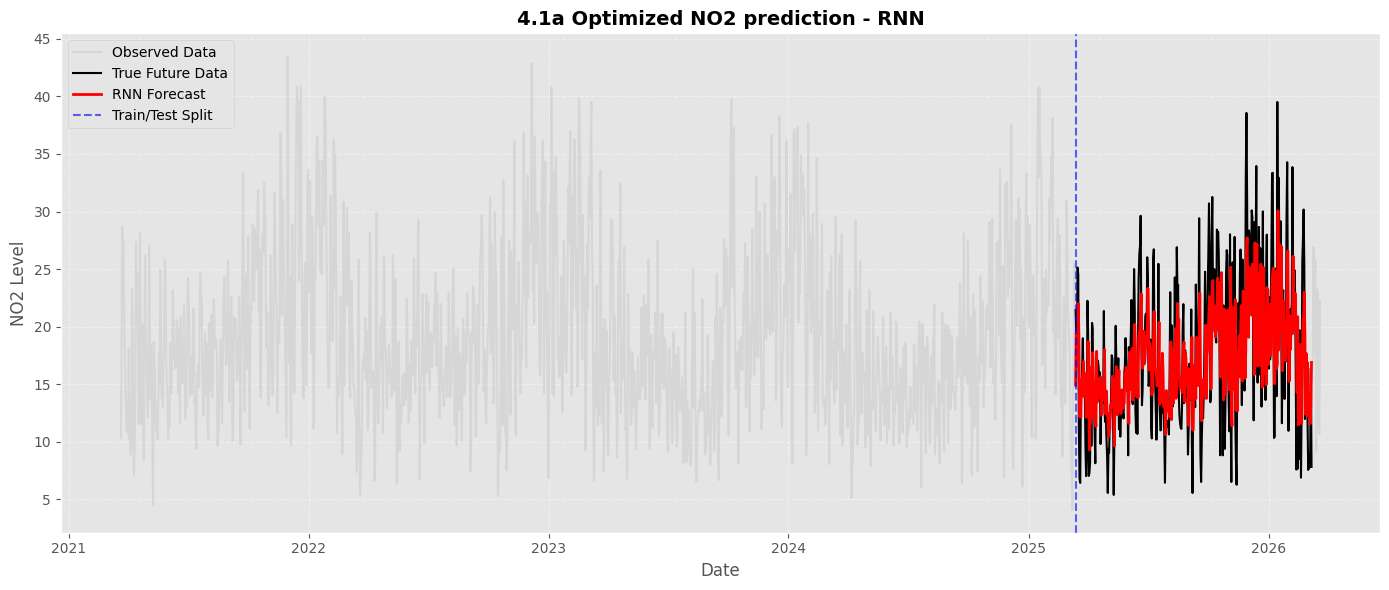

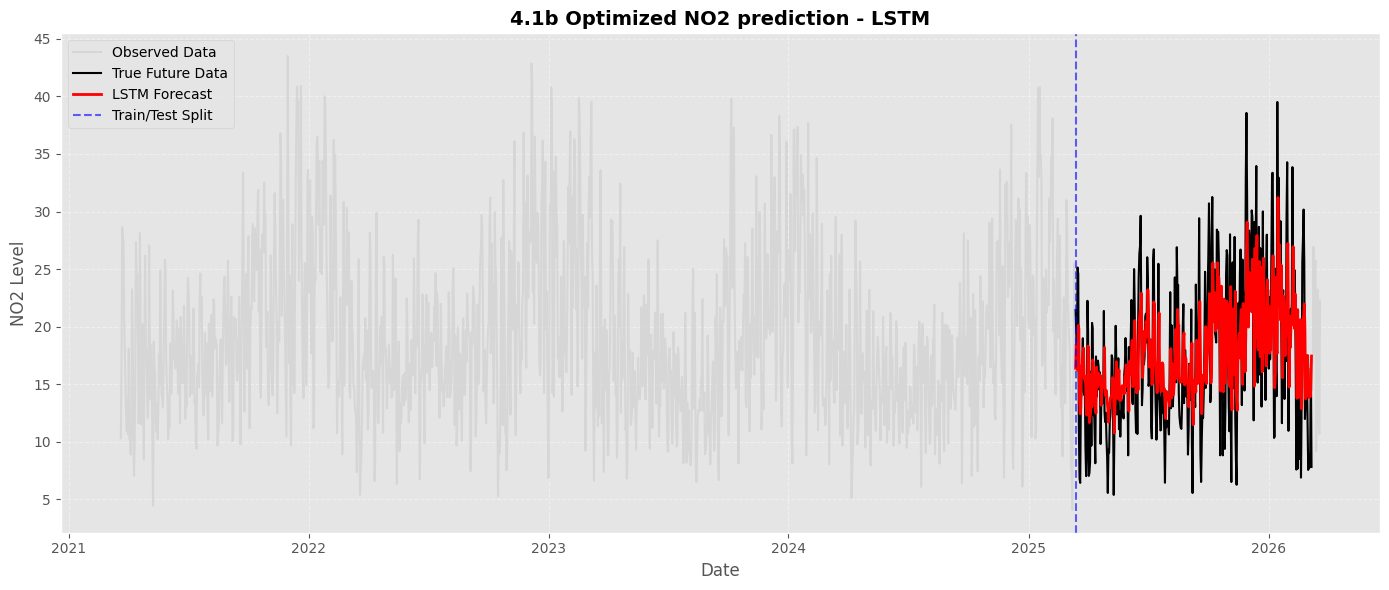

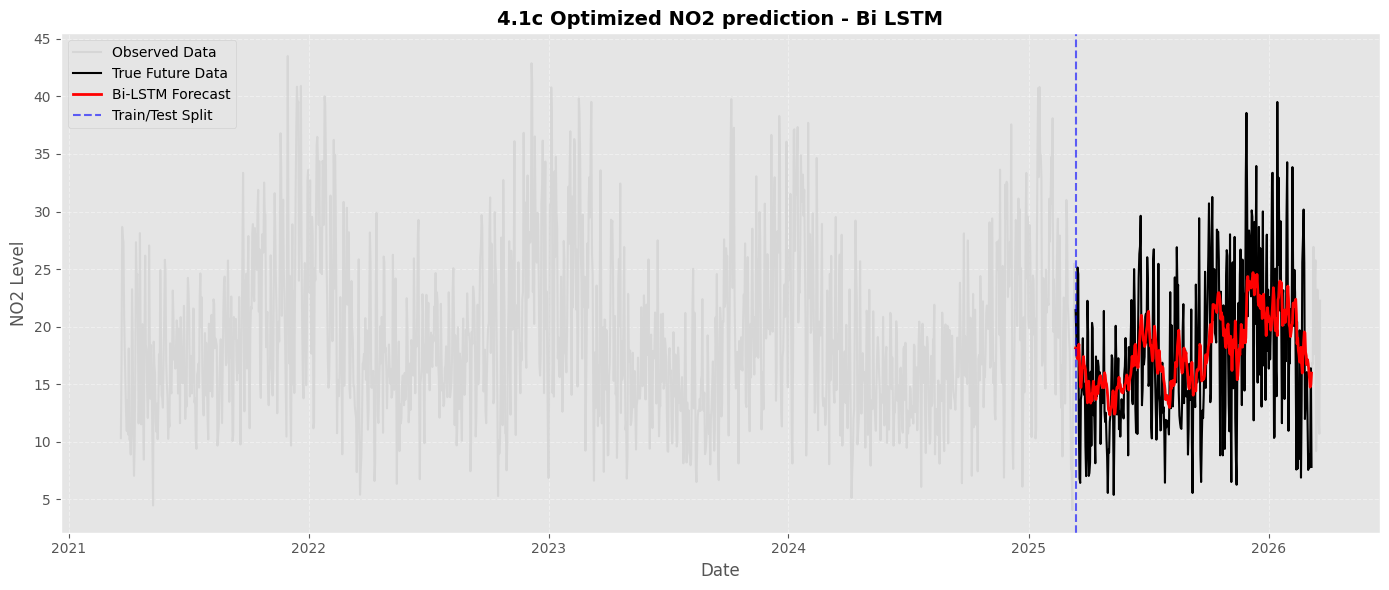

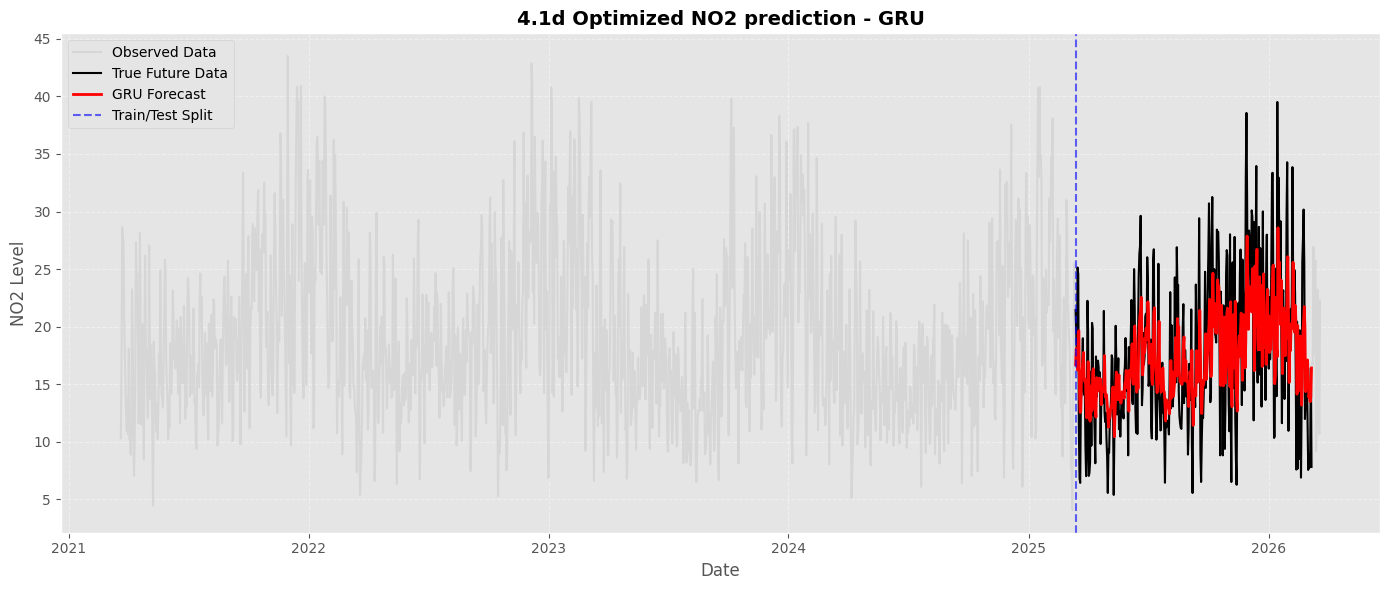

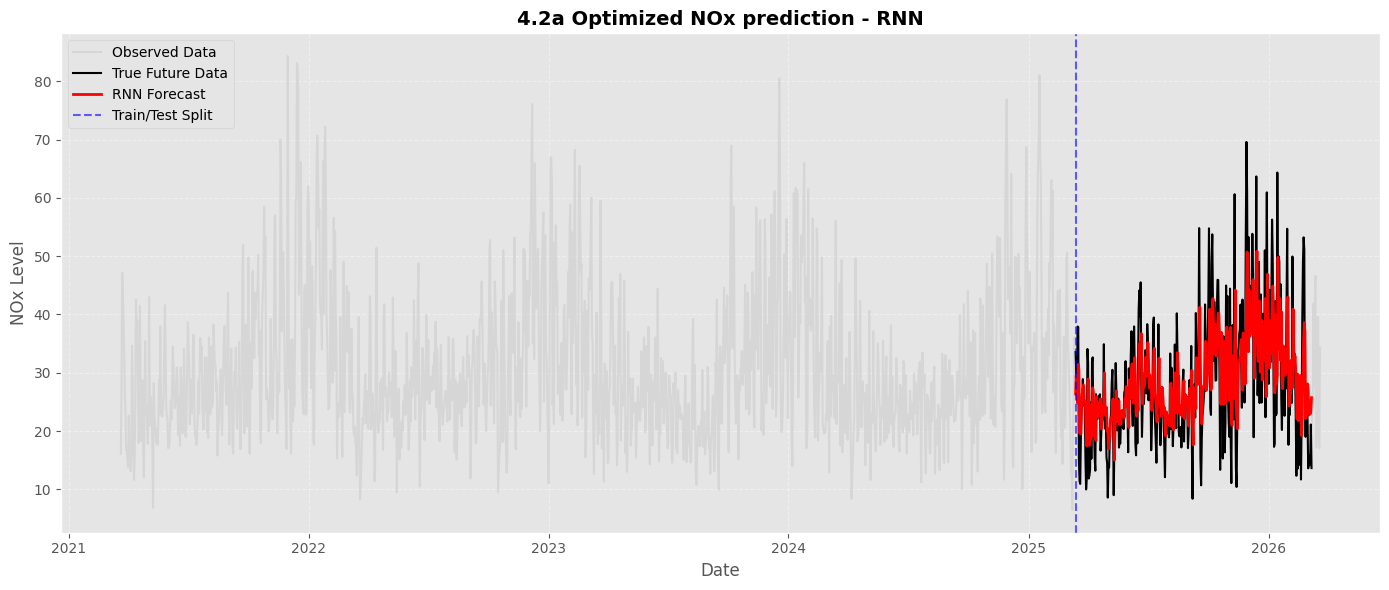

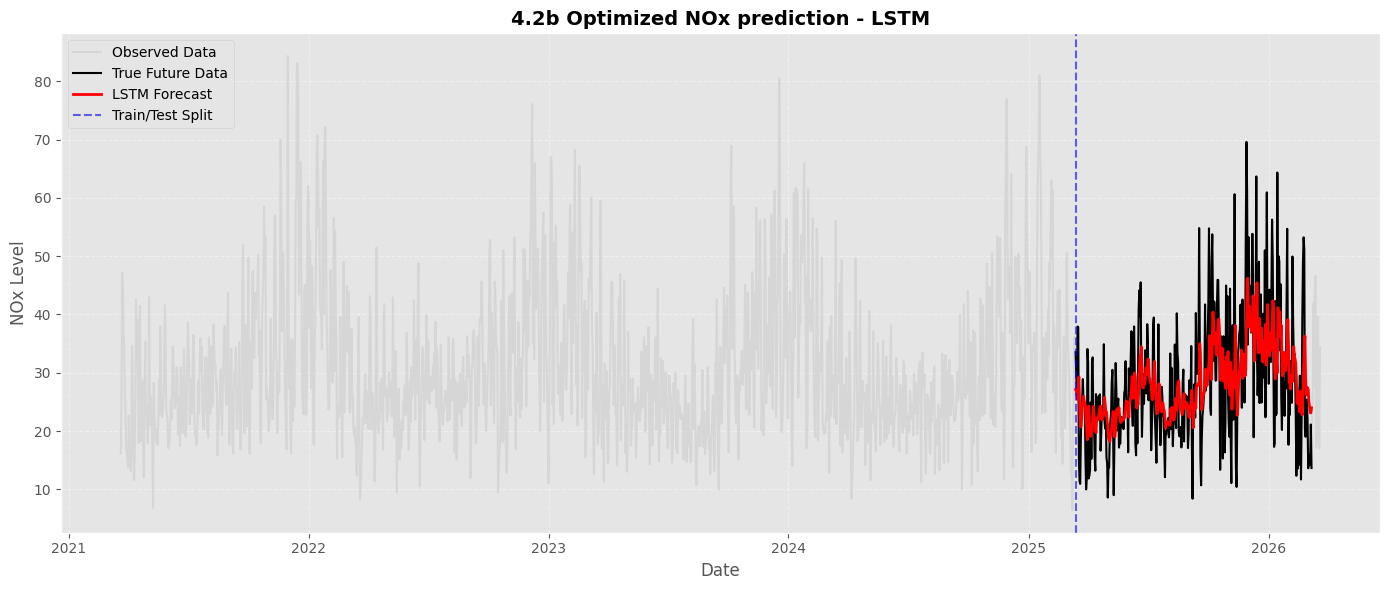

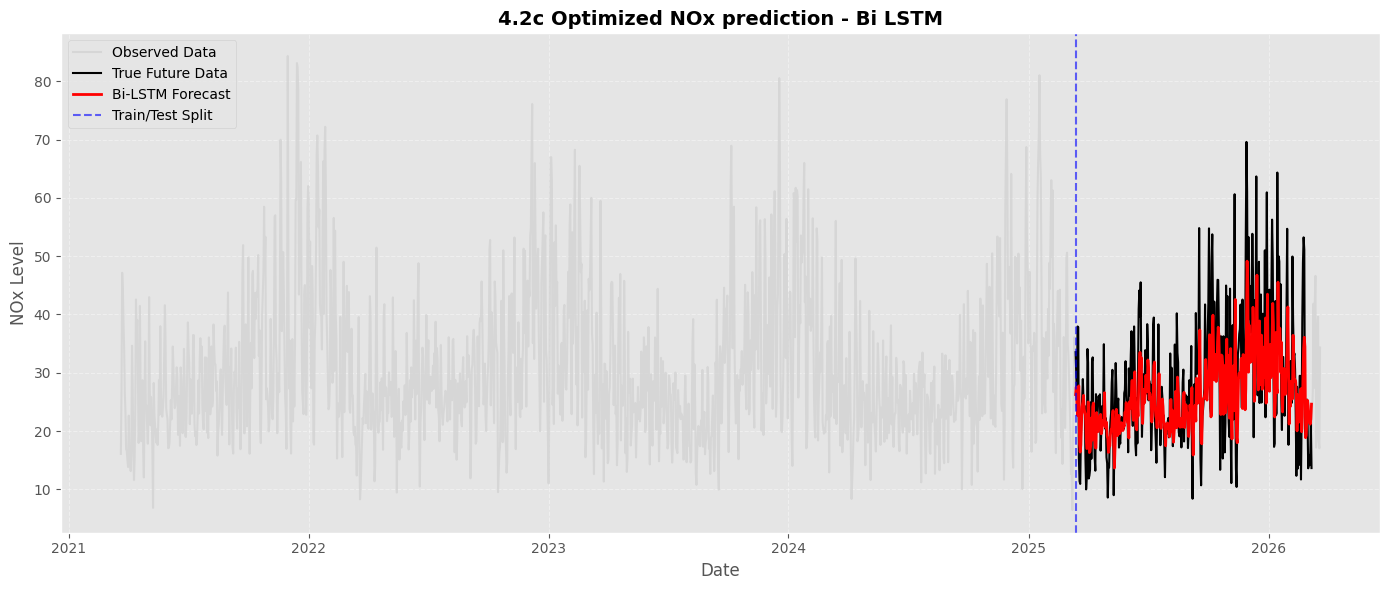

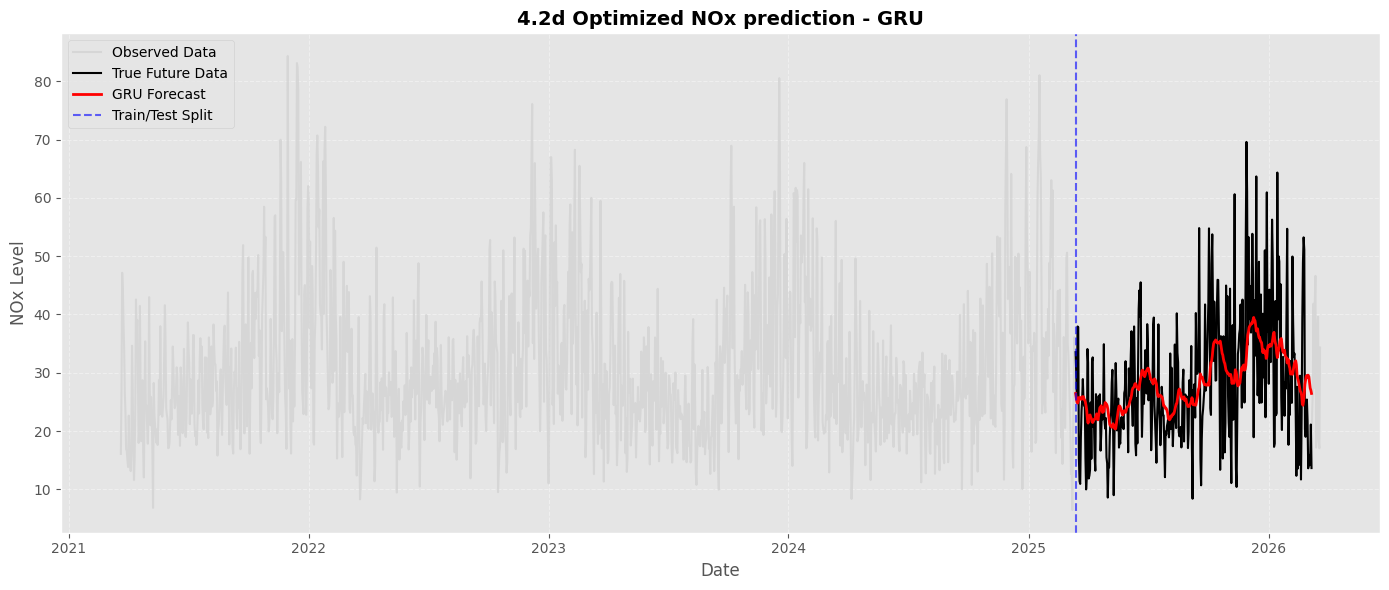

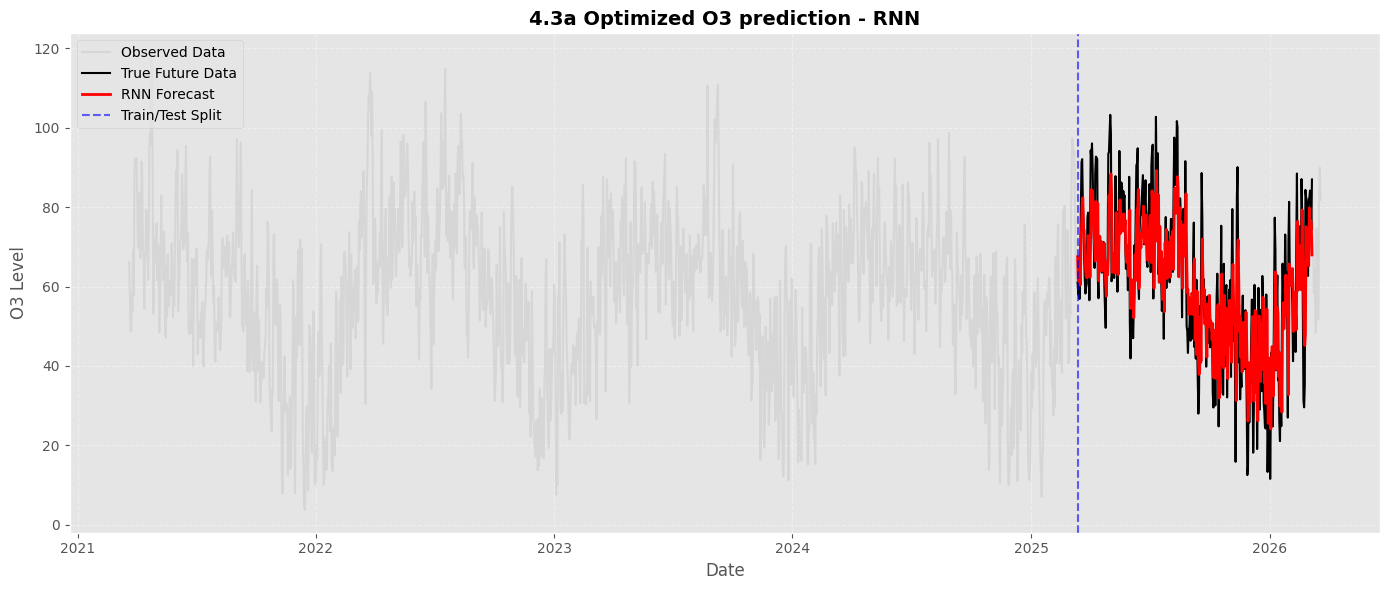

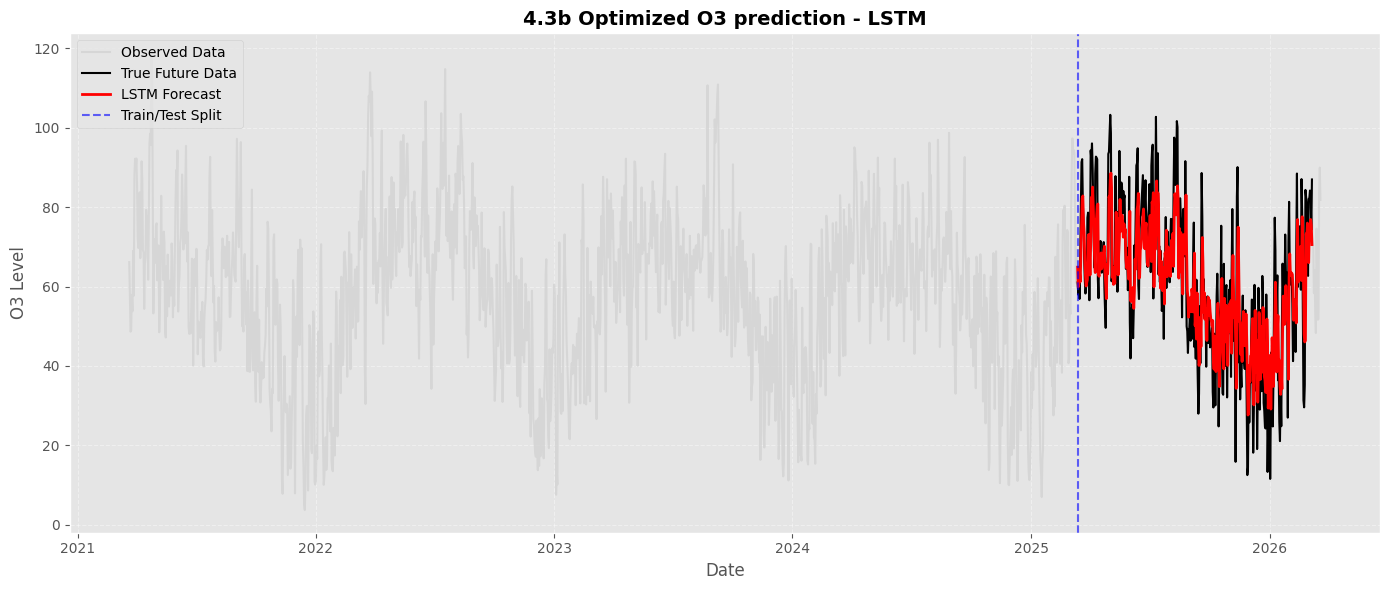

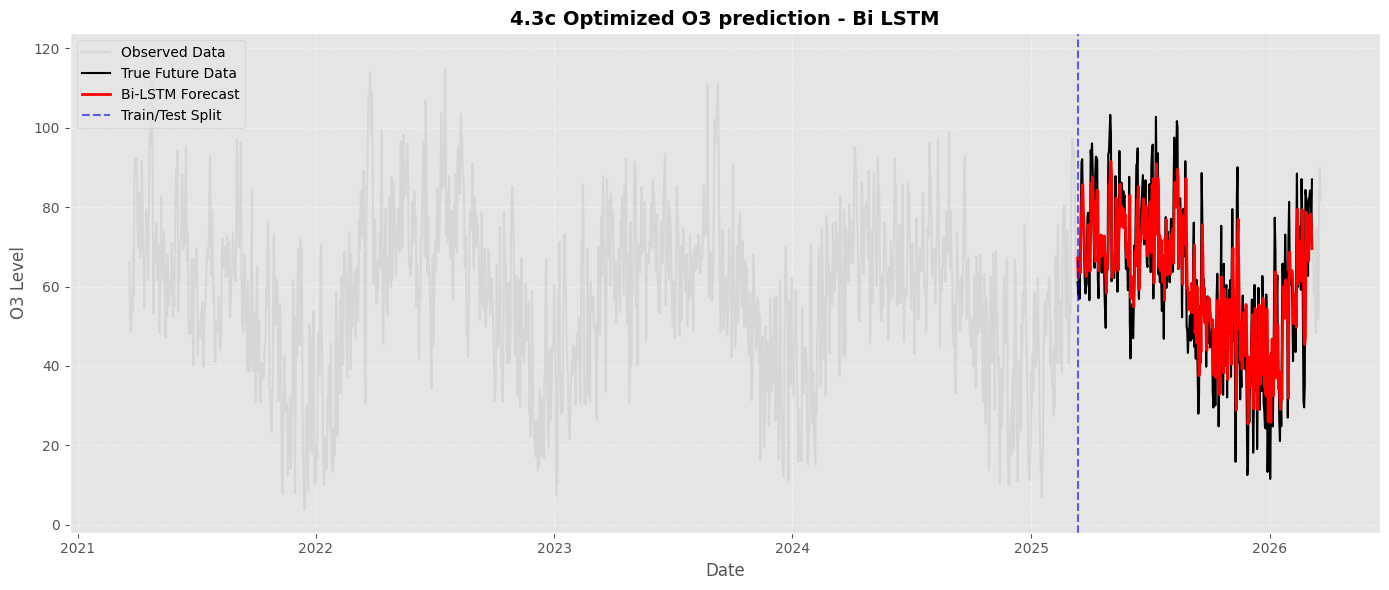

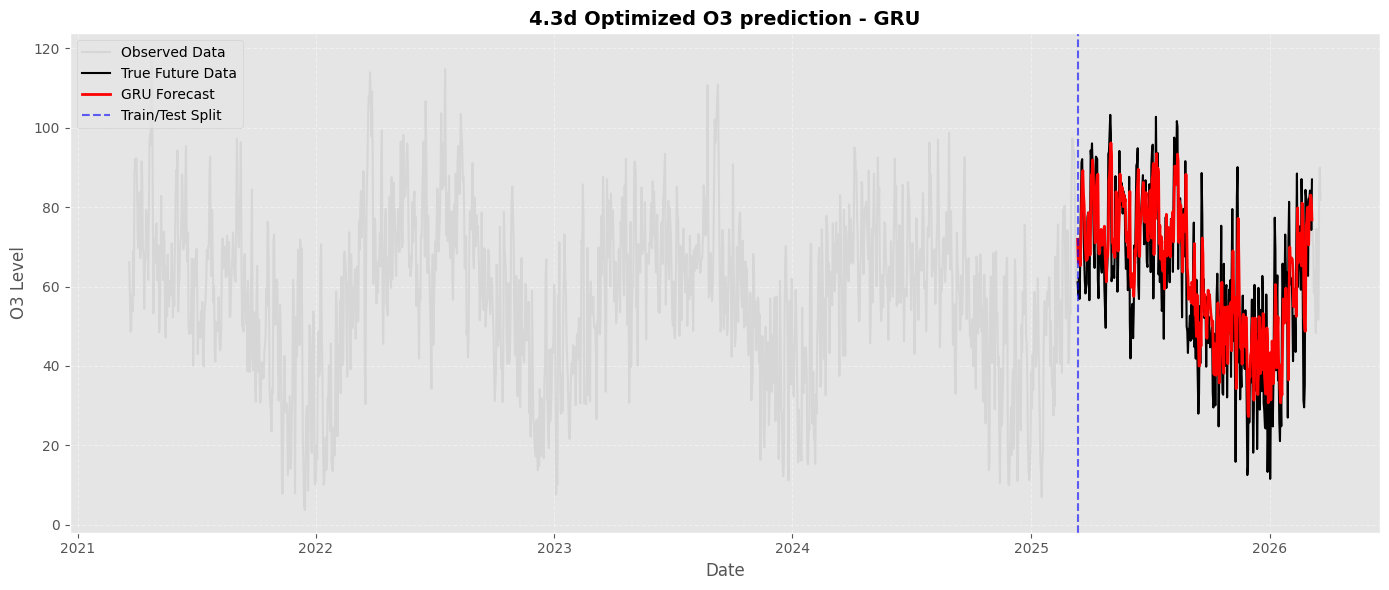

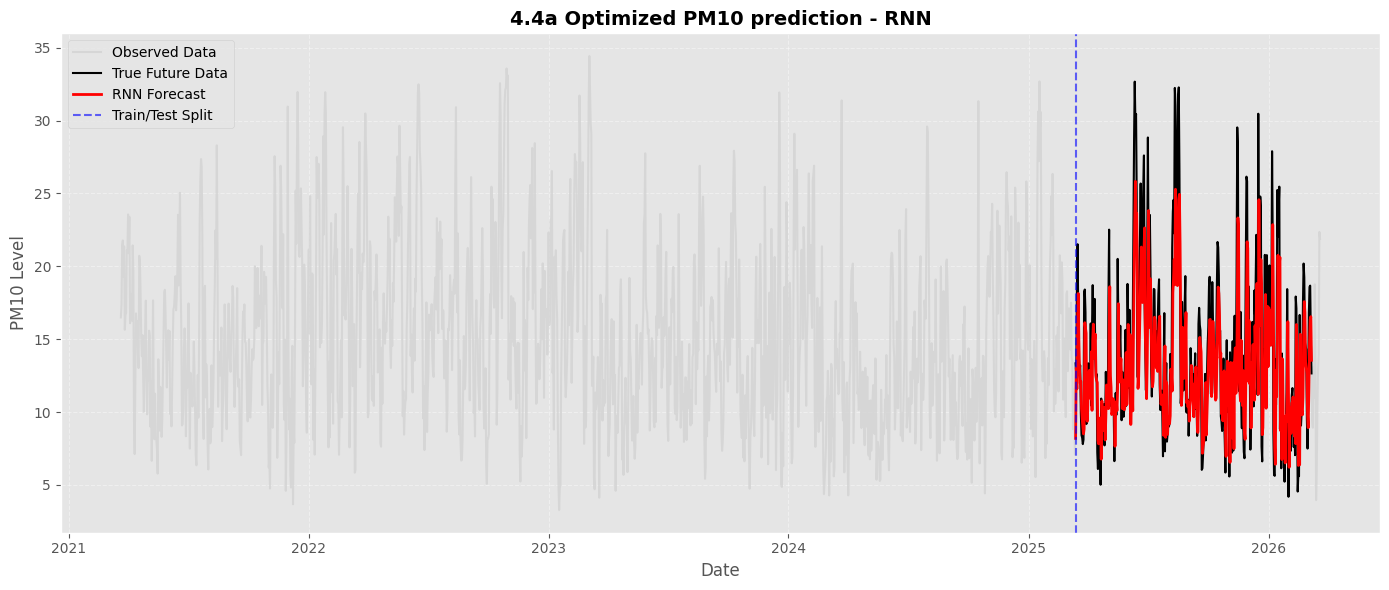

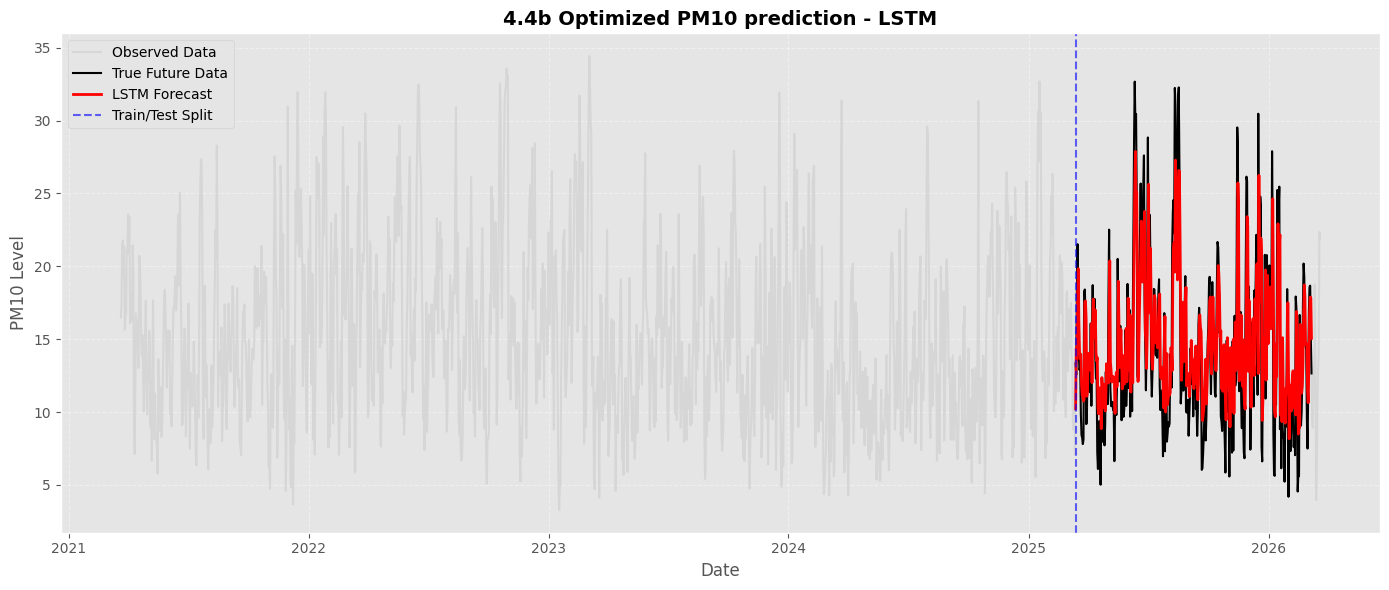

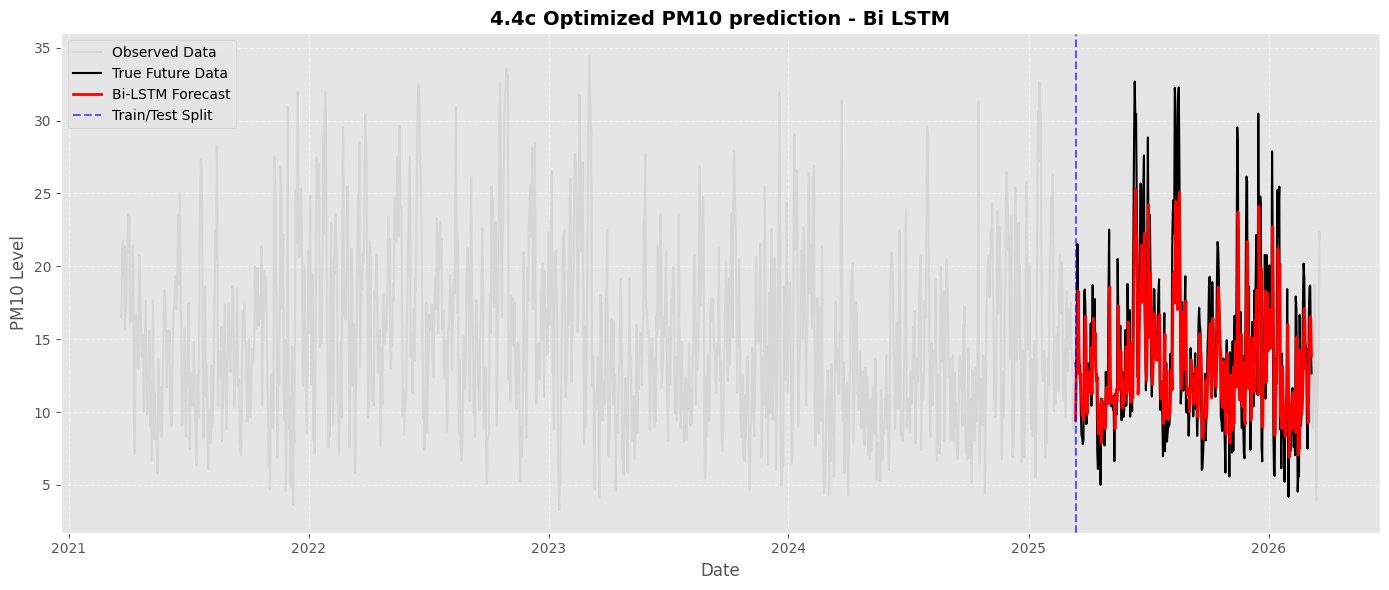

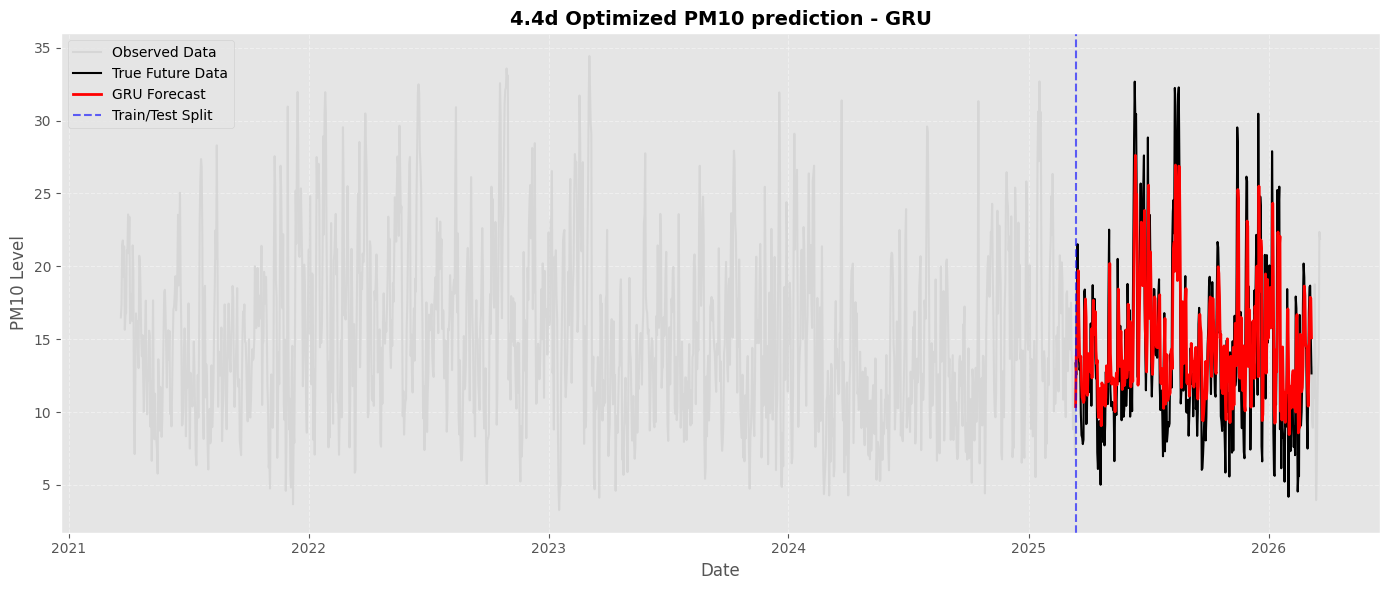

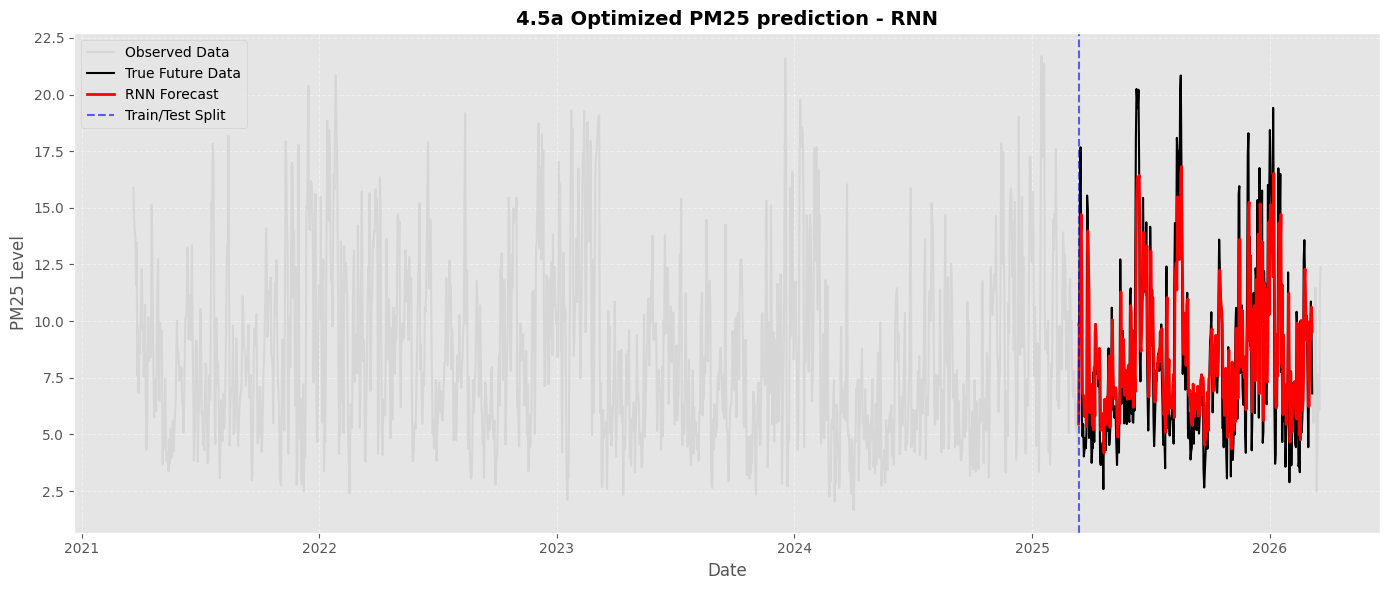

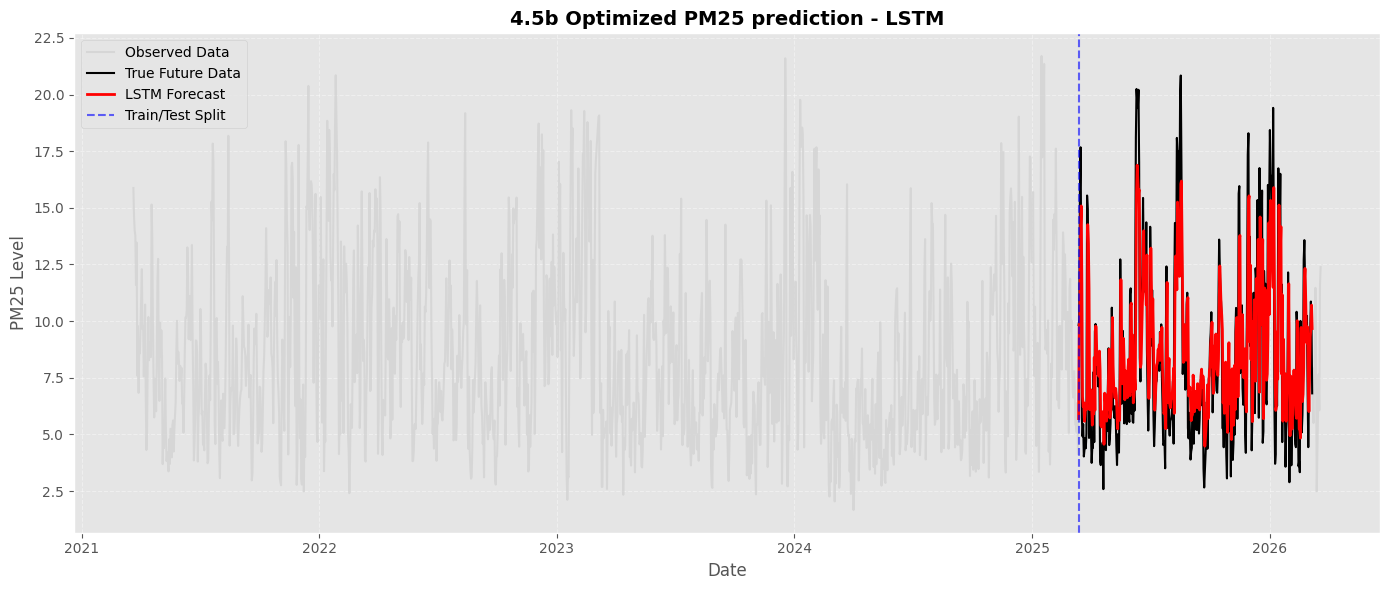

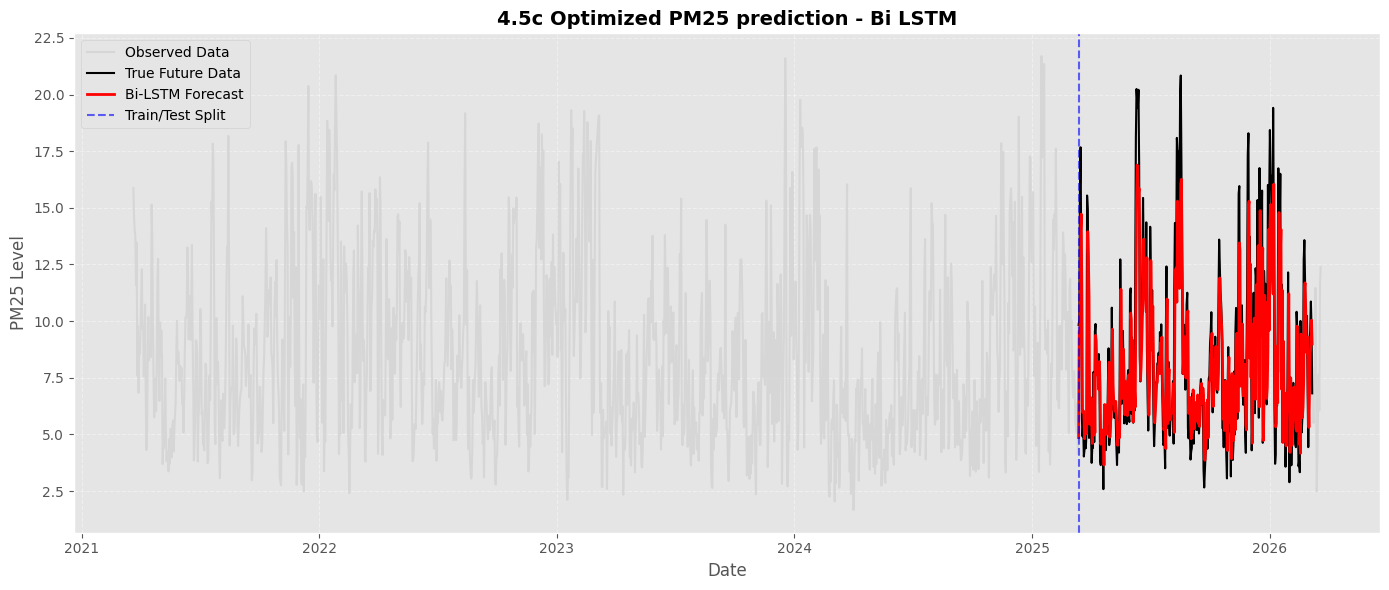

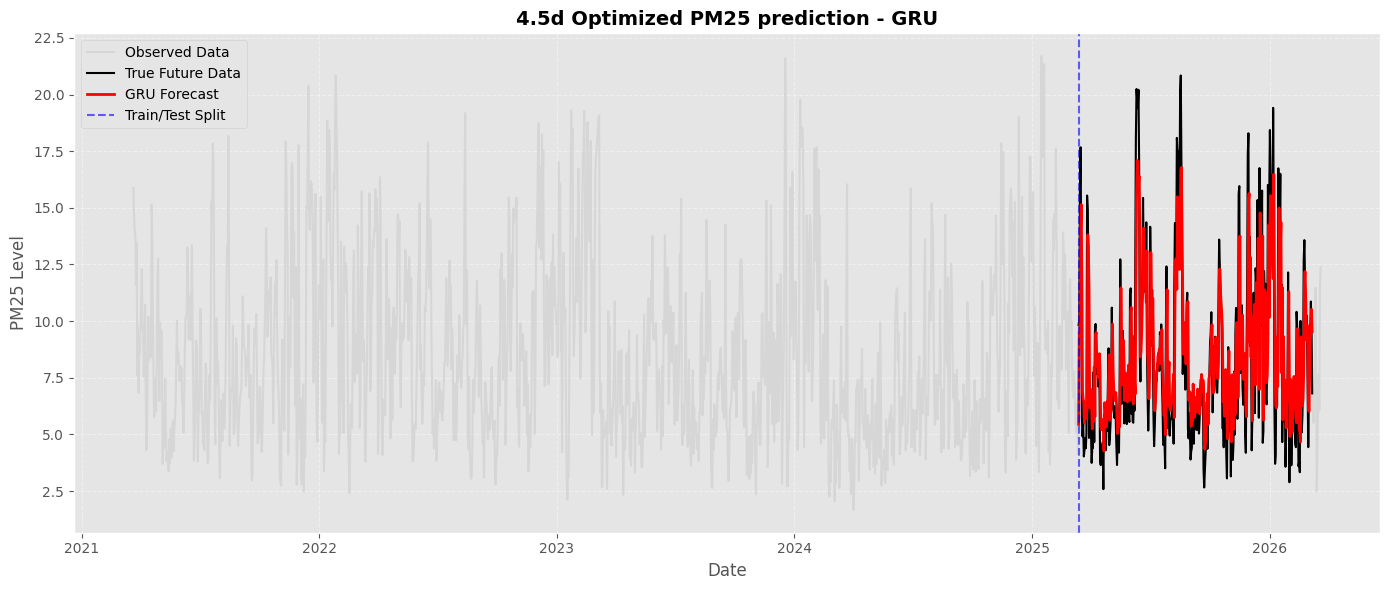

In [10]:
pollutants = ["NO2", "NOx", "O3", "PM10", "PM25"]
rnn_results, lstm_results, bi_lstm_results, gru_results = {}, {}, {}, {}

sv.config.LOOK_BACK = 14
sv.config.HORIZON = 14
sv.config.BATCH_SIZE = 32
sv.config.EPOCHS = 70
sv.config.LEARNING_RATE = 0.001
sv.config.PATIENCE = 50
sv.config.HIDDEN_DIM = 256
sv.config.NUM_LAYERS = 2
sv.config.TEST_FRACTION = 0.2

for idx, pollutant in enumerate(pollutants):
    if pollutant not in df_daily.columns:
        print(f"[!] Skipping {pollutant}: Not found in dataset.")
        continue

    print(f"\n{'=' * 70}\nPOLLUTANT: {pollutant}\n{'=' * 70}")

    train_loader, test_loader, scaler, y_test_orig = sv.prepare_data(df_daily, pollutant, test_fraction=sv.config.TEST_FRACTION)
    print(f" Train samples (80%): {len(train_loader.dataset)}")
    print(f" Test samples (20%): {len(test_loader.dataset)}")

    #- RNN
    title_RNN = f"4.{idx+1}{letters[0]} Optimized {pollutant} prediction - RNN"
    rnn_model = sv.RNNModel(input_dim=1, hidden_dim=sv.config.HIDDEN_DIM, output_dim=sv.config.HORIZON, num_layers=sv.config.NUM_LAYERS)
    rnn_model, _, _ = sv.train_model(rnn_model, train_loader, test_loader, model_name=f"RNN ({pollutant})")
    rnn_metrics, _ = sv.evaluate_model(rnn_model, test_loader, scaler, y_test_orig)
    rnn_results[pollutant] = rnn_metrics
    print(
        f" RNN Metrics: RMSE={rnn_metrics['RMSE']:.3f}, MAE={rnn_metrics['MAE']:.3f}, MAPE={rnn_metrics['MAPE']:.2f}%")
    pred_rnn = sv.predict_and_plot_series(rnn_model,
                                       df_daily, pollutant,
                                       test_loader, scaler,
                                       title=title_RNN,
                                       save_directory=str(OUTPUT_PLOT_DIRECTORY),
                                       model_name="RNN")
    #plt.show()

    #- LSTM
    title_LSTM = f"4.{idx+1}{letters[1]} Optimized {pollutant} prediction - LSTM"
    lstm_model = sv.LSTMModel(input_dim=1, hidden_dim=sv.config.HIDDEN_DIM, output_dim=sv.config.HORIZON, num_layers=sv.config.NUM_LAYERS)
    lstm_model, _, _ = sv.train_model(lstm_model, train_loader, test_loader, model_name=f"LSTM ({pollutant})")
    lstm_metrics, _ = sv.evaluate_model(lstm_model, test_loader, scaler, y_test_orig)
    lstm_results[pollutant] = lstm_metrics
    print(
        f" LSTM Metrics: RMSE={lstm_metrics['RMSE']:.3f}, MAE={lstm_metrics['MAE']:.3f}, MAPE={lstm_metrics['MAPE']:.2f}%")
    pred_lstm = sv.predict_and_plot_series(lstm_model,
                                        df_daily, pollutant,
                                        test_loader, scaler,
                                       title=title_LSTM,
                                       save_directory=str(OUTPUT_PLOT_DIRECTORY),
                                        model_name="LSTM")
    #plt.show()

    #- Bi-LSTM
    title_bi_lstm = f"4.{idx+1}{letters[2]} Optimized {pollutant} prediction - Bi LSTM"
    bi_lstm_model = sv.BiLSTMModel(input_dim=1, hidden_dim=sv.config.HIDDEN_DIM, output_dim=sv.config.HORIZON, num_layers=sv.config.NUM_LAYERS)
    bi_lstm_model, _, _ = sv.train_model(bi_lstm_model, train_loader, test_loader, model_name=f"Bi-LSTM ({pollutant})")
    bi_lstm_metrics, _ = sv.evaluate_model(bi_lstm_model, test_loader, scaler, y_test_orig)
    bi_lstm_results[pollutant] = bi_lstm_metrics
    print(
        f"Bi-LSTM Metrics: RMSE={bi_lstm_metrics['RMSE']:.3f}, MAE={bi_lstm_metrics['MAE']:.3f},"
        f"MAPE={bi_lstm_metrics['MAPE']:.2f}%")
    pred_bi_lstm = sv.predict_and_plot_series(bi_lstm_model,
                                           df_daily, pollutant,
                                           test_loader, scaler,
                                              title=title_bi_lstm,
                                              save_directory=str(OUTPUT_PLOT_DIRECTORY),
                                           model_name="Bi-LSTM")
    #plt.show()

    #- GRU
    title_GRU = f"4.{idx+1}{letters[3]} Optimized {pollutant} prediction - GRU"
    gru_model = sv.LSTMModel(input_dim=1, hidden_dim=sv.config.HIDDEN_DIM, output_dim=sv.config.HORIZON, num_layers=sv.config.NUM_LAYERS)
    gru_model, _, _ = sv.train_model(gru_model, train_loader, test_loader, model_name=f"GRU ({pollutant})")
    gru_metrics, _ = sv.evaluate_model(gru_model, test_loader, scaler, y_test_orig)
    gru_results[pollutant] = gru_metrics
    print(
        f" GRU Metrics: RMSE={gru_metrics['RMSE']:.3f}, MAE={gru_metrics['MAE']:.3f}, MAPE={gru_metrics['MAPE']:.2f}%")
    pred_gru = sv.predict_and_plot_series(gru_model,
                                       df_daily, pollutant,
                                       test_loader, scaler,
                                          title=title_GRU,
                                          save_directory=str(OUTPUT_PLOT_DIRECTORY),
                                       model_name="GRU")

In [11]:
print("\n" + "=" * 70 + "\nSaving results...")
deep_learning_single_variable = "outputs/sv_results_04.pkl"
with open(deep_learning_single_variable, "wb") as f:
    pickle.dump({"rnn_results": rnn_results, "lstm_results": lstm_results, "bi_lstm_results": bi_lstm_results, "gru_results": gru_results}, f)
print(f"[✓] Neural network results saved to {deep_learning_single_variable}")
print("\n" + "=" * 70 + "\nPart 3.1 Complete!\n" + "=" * 70)


Saving results...
[✓] Neural network results saved to outputs/sv_results_04.pkl

Part 3.1 Complete!


## Multivariate data



FEATURE SELECTION: Spearman Correlation
[✓] Correlation heatmap saved to 'outputs/plots/correlation_heatmap.png'


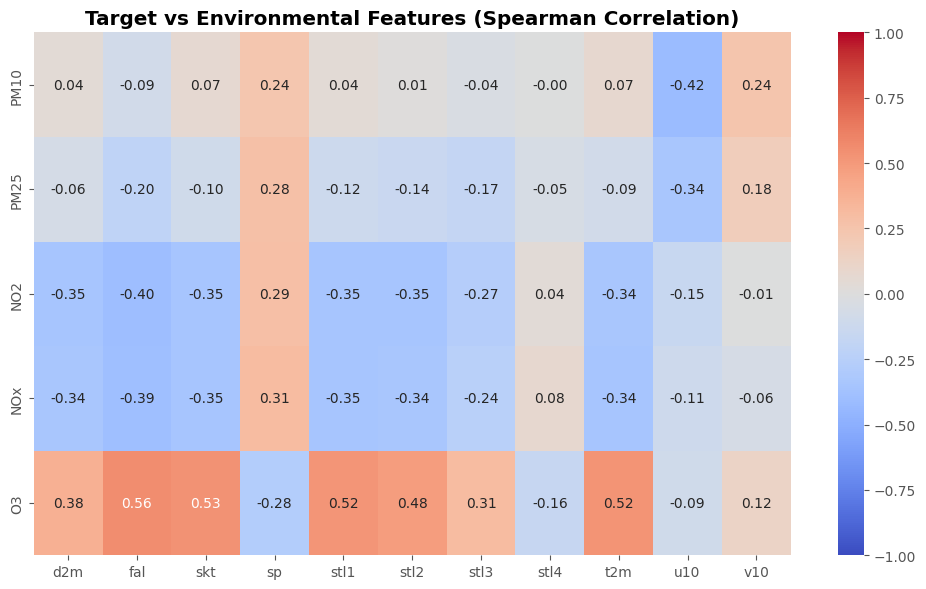


 Top 3 Predictors for PM10:
   -> u10: -0.416
   -> v10: 0.244
   -> sp: 0.235

 Top 3 Predictors for PM25:
   -> u10: -0.338
   -> sp: 0.279
   -> fal: -0.204

 Top 3 Predictors for NO2:
   -> fal: -0.399
   -> stl1: -0.350
   -> stl2: -0.348

 Top 3 Predictors for NOx:
   -> fal: -0.395
   -> skt: -0.347
   -> stl1: -0.347

 Top 3 Predictors for O3:
   -> fal: 0.562
   -> skt: 0.533
   -> t2m: 0.525


In [12]:
optimal_features_dict = {}
if not final_dataset.empty:
    targets = ["PM10", "PM25", "NO2", "NOx", "O3"]

    # Safely identify targets that exist in the dataframe
    valid_targets = [col for col in targets if col in final_dataset.columns]

    # Identify all columns that are NOT targets (these are our weather features)
    all_weather_features = [col for col in final_dataset.columns if col not in valid_targets]

    # --- Run Feature Selection ---
    if valid_targets and all_weather_features:
        title = "4.6 Correlation between weather variables and pollutants throughout the analysed period"
        parquet_path = OUTPUT_PLOT_DIRECTORY/Path(title+'.png')

        optimal_features_dict = analyze_feature_correlations(
            df=final_dataset,
            targets=valid_targets,
            features=all_weather_features,
            top_k=3,
            save_directory=parquet_path,
            method='spearman'
        )


In [13]:
mv.config.LOOK_BACK = 30
mv.config.HORIZON = 14
mv.config.BATCH_SIZE = 32
mv.config.EPOCHS = 70
mv.config.LEARNING_RATE = 0.001
mv.config.PATIENCE = 50
mv.config.HIDDEN_DIM = 256
mv.config.NUM_LAYERS = 2
mv.config.TEST_FRACTION = 0.2

targets = ["NO2", "NOx", "O3", "PM10", "PM25"]

lstm_results = {}
bilstm_results = {}

for idx, target in enumerate(targets):
    # 1. Define exactly what we want to keep
    wanted_features = optimal_features_dict[target]

    # 2. Combine wanted weather features with our target pollutants
    columns_to_keep = targets + wanted_features

    # 3. Filter safely (only keep columns that actually exist in the dataframe)
    feature_cols = [col for col in columns_to_keep if col in df_daily.columns]

    # 4. Overwrite the dataframe with only the selected columns
    df_daily = df_daily[feature_cols]

    print(f"[✓] Extracted {len(feature_cols)} features for Autoregression & Multivariate learning. - {feature_cols}")
    if target not in df_daily.columns:
        print(f"[!] Skipping {target}: Not found in dataset.")
        continue

    print(f"\n{'=' * 70}\nTARGET POLLUTANT: {target}\n{'=' * 70}")

    try:
        train_loader, test_loader, scaler, y_test_orig, num_features = mv.prepare_multivariate_data(
            df_daily, target_col=target, feature_cols=feature_cols
        )
    except ValueError as e:
        print(e)
        continue

    #- Standard LSTM
    title = f"4.{idx+8}{letters[0]} Optimized multivariate {target} prediction - LSTM"
    lstm_model = mv.LSTMModel(input_dim=num_features, hidden_dim=mv.config.HIDDEN_DIM, output_dim=mv.config.HORIZON, num_layers=mv.config.NUM_LAYERS)
    lstm_model = mv.train_model(lstm_model, train_loader, test_loader, model_name=f"LSTM ({target})")
    lstm_metrics = mv.evaluate_and_plot(
        lstm_model,
        df_daily,
        target,
        test_loader,
        scaler,
        y_test_orig,
        title=title,
        save_directory=str(OUTPUT_PLOT_DIRECTORY),
        model_name="LSTM")
    lstm_results[target] = lstm_metrics
    print(
        f" LSTM Metrics: RMSE={lstm_metrics['RMSE']:.3f}, MAE={lstm_metrics['MAE']:.3f}, MAPE={lstm_metrics['MAPE']:.2f}%")


    #- Bi-Directional LSTM
    title = f"4.{idx+8}{letters[1]} Optimized multivariate {target} prediction - Bi LSTM"
    bilstm_model = mv.BiLSTMModel(input_dim=num_features, hidden_dim=mv.config.HIDDEN_DIM, output_dim=mv.config.HORIZON, num_layers=mv.config.NUM_LAYERS)
    bilstm_model = mv.train_model(bilstm_model, train_loader, test_loader, model_name=f"Bi-LSTM ({target})")
    bilstm_metrics = mv.evaluate_and_plot(
        bilstm_model,
        df_daily,
        target,
        test_loader,
        scaler,
        y_test_orig,
        title=title,
        save_directory=str(OUTPUT_PLOT_DIRECTORY),
        model_name="Bi-LSTM")
    bilstm_results[target] = bilstm_metrics
    lstm_results[target] = lstm_metrics
    print(
        f" LSTM Metrics: RMSE={bilstm_metrics['RMSE']:.3f}, MAE={bilstm_metrics['MAE']:.3f}, MAPE={bilstm_metrics['MAPE']:.2f}%")



[✓] Extracted 8 features for Autoregression & Multivariate learning. - ['NO2', 'NOx', 'O3', 'PM10', 'PM25', 'fal', 'stl1', 'stl2']

TARGET POLLUTANT: NO2

Training LSTM (NO2)...
 Epoch   1/70: Train=0.04941, Val=0.02516 [NEW BEST]
 Epoch   2/70: Train=0.02700, Val=0.02424 [NEW BEST]
 Epoch   3/70: Train=0.02617, Val=0.02386 [NEW BEST]
 Epoch  10/70: Train=0.02519, Val=0.02784 (Patience 7/70)
 Epoch  20/70: Train=0.02394, Val=0.02632 (Patience 17/70)
 Epoch  30/70: Train=0.02300, Val=0.02798 (Patience 27/70)
 Epoch  40/70: Train=0.02079, Val=0.02722 (Patience 8/70)
 Epoch  50/70: Train=0.01568, Val=0.03042 (Patience 18/70)
 Epoch  60/70: Train=0.01139, Val=0.03484 (Patience 28/70)
 Epoch  70/70: Train=0.00859, Val=0.03180 (Patience 38/70)
[✓] Forecast plot saved successfully to: C:\Users\Tiago\Documents - PC\UTTOP\Enseignements\M1.2\Projet AirTS - Forecast\DL PLOTS\4.8a Optimized multivariate NO2 prediction - LSTM.png
 LSTM Metrics: RMSE=6.054, MAE=4.851, MAPE=33.72%

Training Bi-LSTM (

In [14]:
# Save results
deep_learning_multivariate = "outputs/mv_results_04.pkl"
with open(deep_learning_multivariate, "wb") as f:
    pickle.dump({"lstm_results": lstm_results, "bilstm_results": bilstm_results}, f)
print(f"[✓] Neural network results saved to {deep_learning_multivariate}")
print("\n" + "=" * 70 + "\nPart 3.2 Complete!\n" + "=" * 70)

[✓] Neural network results saved to outputs/mv_results_04.pkl

Part 3.2 Complete!


## Model comparison

[✓] Loaded classical model results from Part 2
[✓] Loaded neural network results from Part 3

DATA STATUS — Which results are real vs fallback?
{'ARIMA': {'RMSE': 7.323918056502762, 'MAE': 6.288796918598242, 'MAPE': 65.47609041130481}, 'SARIMA': {'RMSE': 6.015246815693989, 'MAE': 5.166519708431552, 'MAPE': 51.95420219128771}, 'Holt-Winters': {'RMSE': 5.891213239291995, 'MAE': 4.847343177722151, 'MAPE': 38.660582843528985}}
NO2  : [✓] ARIMA, [✓] SARIMA, [✓] Holt-Winters, [✓] RNN, [✓] GRU, [✓] LSTM, [-] Bi-LSTM (fallback)
{'ARIMA': {'RMSE': 5.641974819828949, 'MAE': 4.84979740715374, 'MAPE': 51.323105437615254}, 'SARIMA': {'RMSE': 3.6785075973282697, 'MAE': 3.2064114569011104, 'MAPE': 31.79858641396513}, 'Holt-Winters': {'RMSE': 3.3061493992630293, 'MAE': 2.700605968924845, 'MAPE': 24.402444932621478}}
PM10 : [✓] ARIMA, [✓] SARIMA, [✓] Holt-Winters, [✓] RNN, [✓] GRU, [✓] LSTM, [-] Bi-LSTM (fallback)
{'ARIMA': {'RMSE': 4.323081453897308, 'MAE': 4.080429930072865, 'MAPE': 74.40708879690114

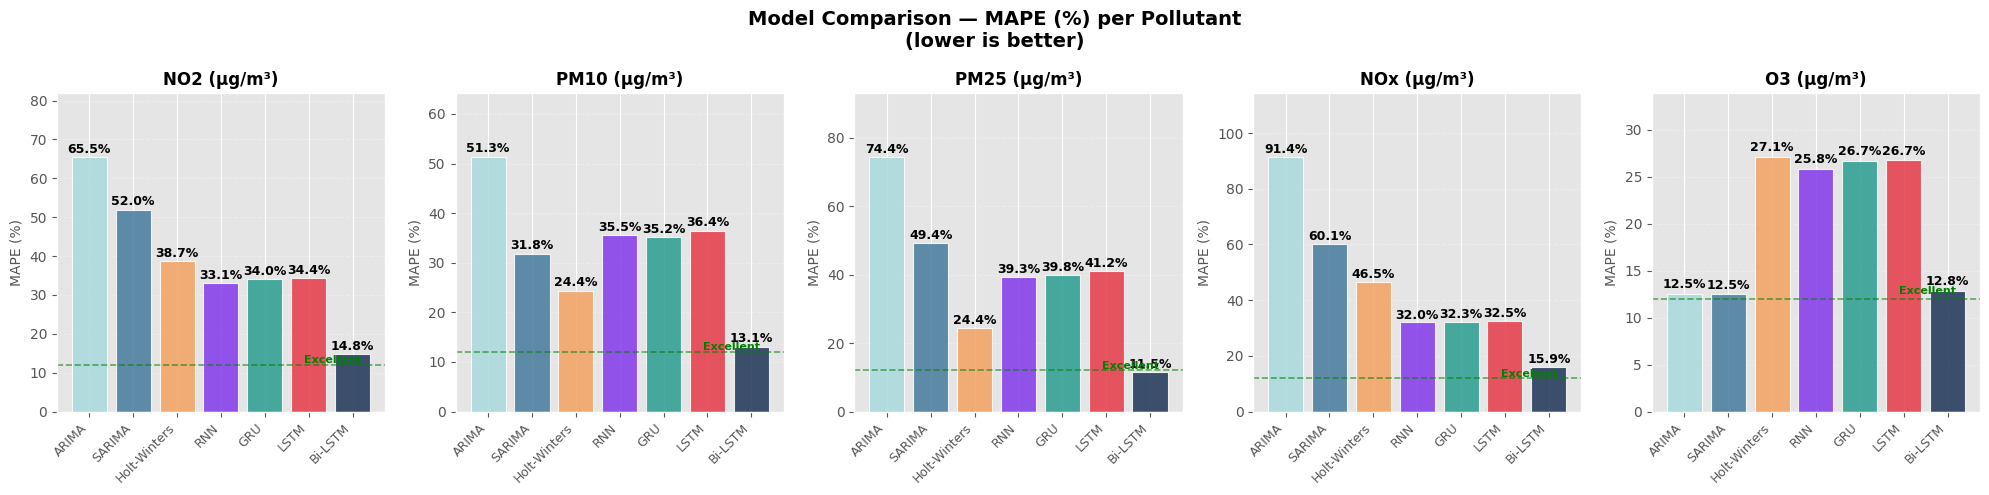

[✓] Figure saved: outputs/13_radar_comparison.png


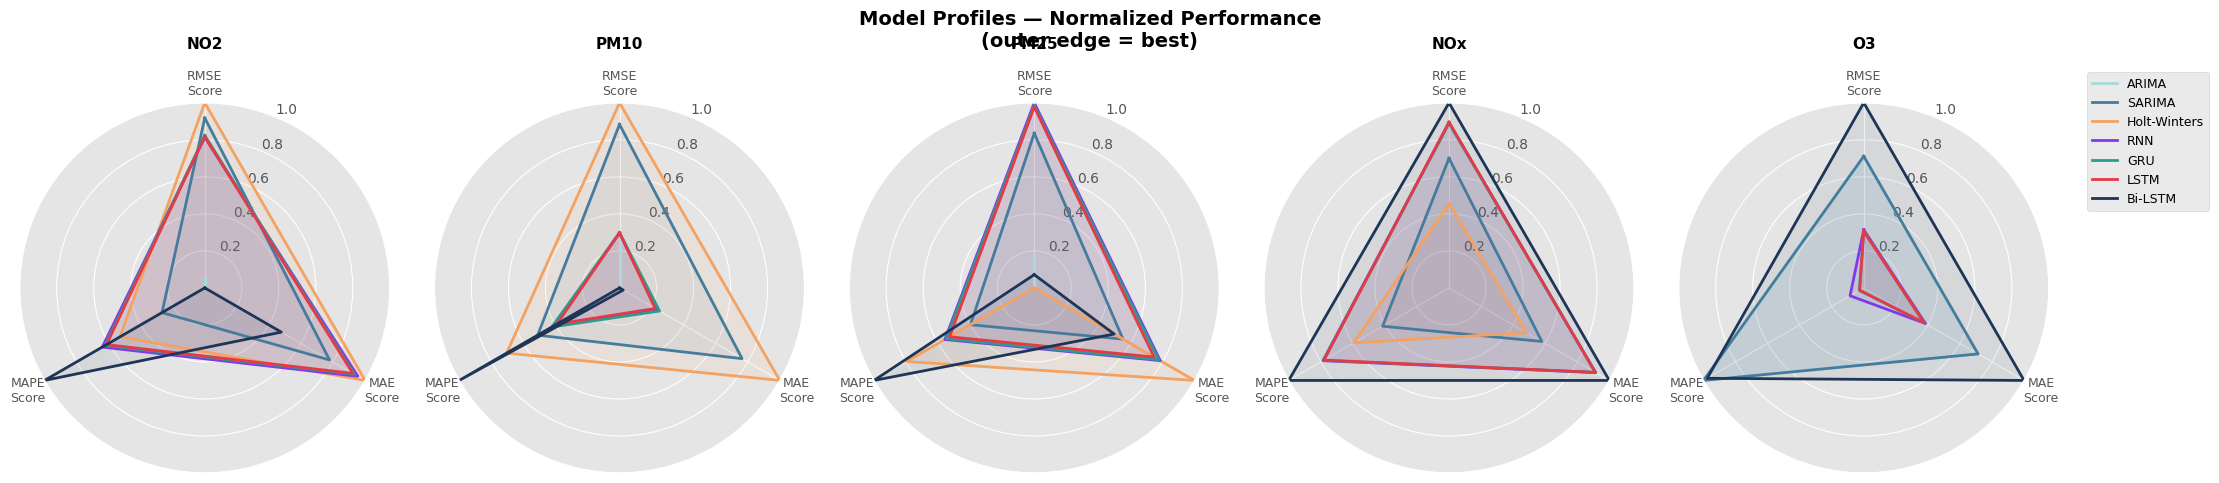


COMPREHENSIVE RESULTS — MAPE (%) ALL MODELS × ALL POLLUTANTS
Model                    NO2         PM10         PM25          NOx           O3
-----------------------------------------------------------------------------------------------
ARIMA                  65.5%        51.3%        74.4%        91.4%        12.5%
SARIMA                 52.0%        31.8%        49.4%        60.1%        12.5%
Holt-Winters           38.7%        24.4%        24.4%        46.5%        27.1%
RNN                    33.1%        35.5%        39.3%        32.0%        25.8%
GRU                    34.0%        35.2%        39.8%        32.3%        26.7%
LSTM                   34.4%        36.4%        41.2%        32.5%        26.7%
Bi-LSTM                14.8%        13.1%        11.5%        15.9%        12.8%  <-- BEST
-----------------------------------------------------------------------------------------------

Bi-LSTM vs ARIMA (improvement)
                         77% ↓          74% ↓          8

In [15]:
deep_learning_single_variable = "outputs/sv_results_04.pkl"
classical_models = r"C:\Users\Tiago\IdeaProjects\AirTS_Forecast\PollutionDataAnalysis\outputs\classical_model_results.json"
benchmark = load_results(classical_models_filepath=classical_models,deep_learning_models_filepath=deep_learning_single_variable)
plot_mape_bar_chart(benchmark)
plot_radar_charts(benchmark)
print_improvement_table(benchmark)